# Modèle 2 - Random Forest

Le Random Forest est un ensemble d'arbres de décision entraînés sur des sous-échantillons
aléatoires des données et des features. C'est un choix naturel pour un dataset
avec des features hétérogènes (numériques + catégorielles) et des relations non linéaires.

**Avantages :** robuste, peu sensible aux valeurs aberrantes, fournit une feature importance native  
**Limites :** moins interprétable qu'une régression logistique, plus lent à entraîner

In [12]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

from src.data.loader import PROCESSED_DIR
from src.evaluation.metrics import (
    compute_classification_metrics, print_classification_report,
    plot_roc_curve, plot_confusion_matrix, plot_feature_importance
)
from src.models.mlflow_utils import setup_mlflow, log_classification_run, EXPERIMENT_CHURN

plt.rcParams['figure.dpi'] = 110

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.joblib')

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (8000, 58) | Test : (2000, 58)


## 1. Entraînement

In [13]:
# n_estimators=200 : suffisant pour stabiliser les prédictions sans temps de calcul excessif.
# max_depth=15 : évite l'overfitting tout en capturant les interactions non linéaires.
# class_weight='balanced' : compense le déséquilibre 90/10 du churn.
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement terminé.


## 2. Évaluation

In [14]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = compute_classification_metrics(y_test.values, y_pred, y_proba)
print_classification_report(y_test, y_pred, 'Random Forest')

print("\nMétriques :")
for k, v in metrics.items():
    print(f"  {k} : {v:.4f}")


Rapport de classification - Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.91      0.97      0.94      1796
       Churn       0.40      0.21      0.27       204

    accuracy                           0.89      2000
   macro avg       0.66      0.59      0.61      2000
weighted avg       0.86      0.89      0.87      2000


Métriques :
  accuracy : 0.8880
  auc_roc : 0.8093
  f1_weighted : 0.8713
  f1_churn : 0.2727
  precision_churn : 0.4038
  recall_churn : 0.2059
  log_loss : 0.3376


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"AUC-ROC CV (5 plis) : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

AUC-ROC CV (5 plis) : 0.8003 +/- 0.0153


## 3. Visualisations

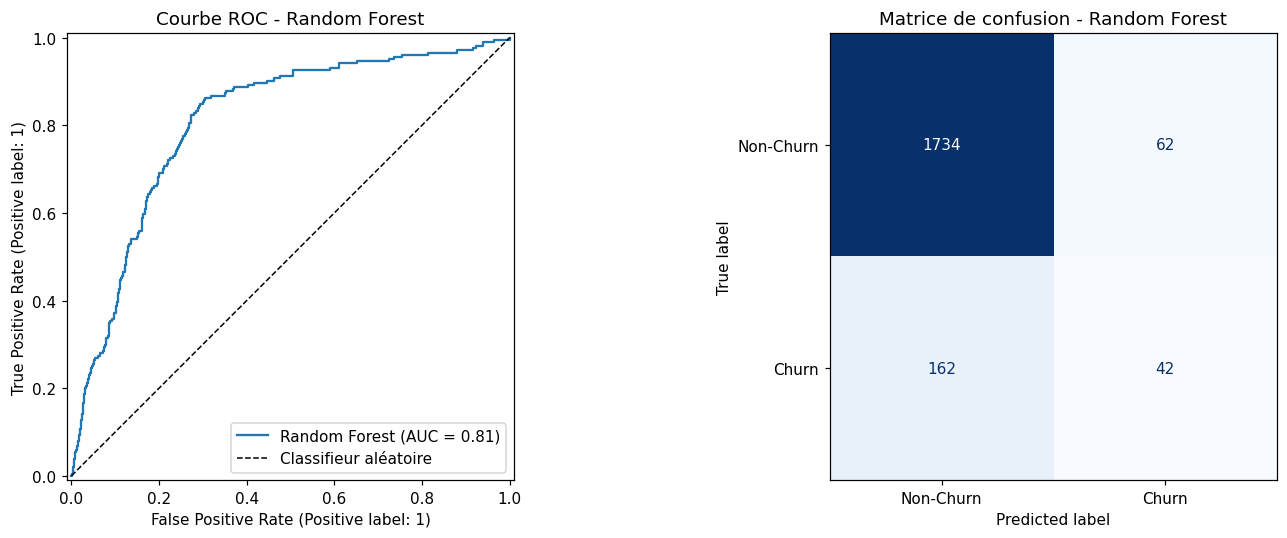

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_roc_curve(model, X_test, y_test, 'Random Forest', ax=axes[0])
plot_confusion_matrix(y_test, y_pred, 'Random Forest', ax=axes[1])
plt.tight_layout()
plt.savefig('../data/processed/fig_rf_roc_cm.png', bbox_inches='tight')
plt.show()

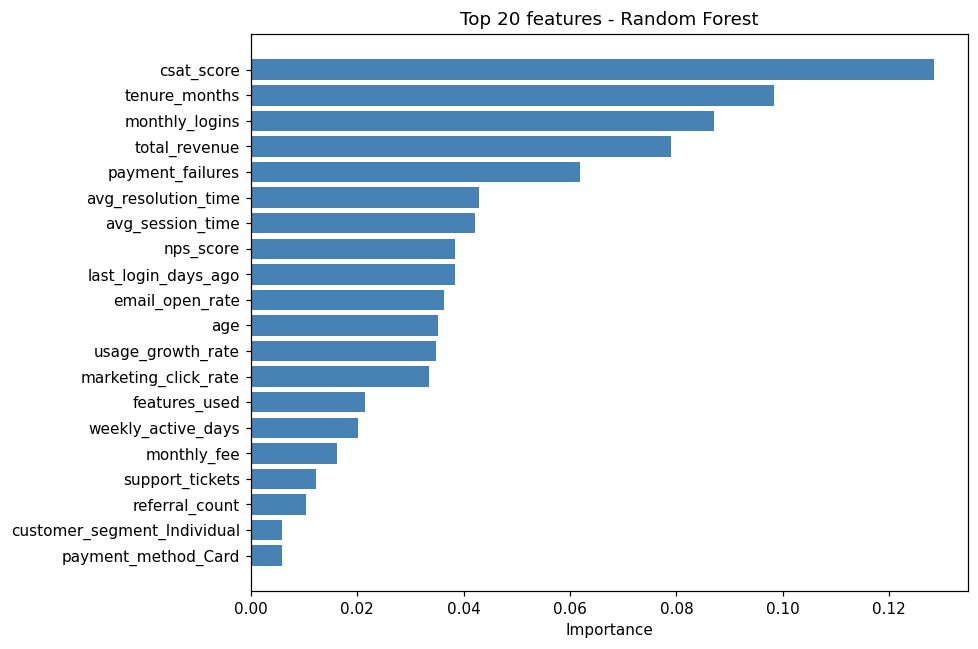

In [17]:
# La feature importance du Random Forest est calculée comme la réduction
# moyenne de l'impureté de Gini à travers tous les arbres - plus fiable
# que les coefficients d'une régression logistique pour des données mixtes.
fig = plot_feature_importance(
    model.feature_importances_, feature_names, 'Random Forest', top_n=20
)
plt.savefig('../data/processed/fig_rf_importance.png', bbox_inches='tight')
plt.show()

## 3b. Optimisation du seuil de decision, amelioration du recall

Avec le seuil par defaut (0.50) le recall churn est seulement **20 %** : on rate 4 churners
sur 5. En abaissant le seuil on classe davantage de clients comme churners, au prix d'une
precision plus faible mais avec un gain metier significatif.

On balaye tous les seuils possibles via la courbe precision-recall et on identifie :
- le seuil qui **maximise le F1-churn** (meilleur compromis precision/recall)
- le seuil qui atteint un **recall cible de 0.80** (approche metier)

In [18]:
from sklearn.metrics import precision_recall_curve
import json

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = (2 * precisions[:-1] * recalls[:-1]
             / (precisions[:-1] + recalls[:-1] + 1e-9))

# Seuil optimal F1
optimal_idx = f1_scores.argmax()
optimal_threshold = float(thresholds[optimal_idx])

# Seuil cible recall >= 0.80
recall_target = 0.80
recall_idx = next((i for i, r in enumerate(recalls[:-1]) if r >= recall_target), None)
threshold_recall80 = float(thresholds[recall_idx]) if recall_idx is not None else None

print(f"Seuil par defaut : 0.50  ->  recall={0.2059:.4f}  F1={0.2727:.4f}")
print(f"Seuil optimal F1 : {optimal_threshold:.4f}  ->  recall={recalls[optimal_idx]:.4f}  "
      f"F1={f1_scores[optimal_idx]:.4f}")
if threshold_recall80 is not None:
    print(f"Seuil recall>=0.80 : {threshold_recall80:.4f}  ->  recall={recalls[recall_idx]:.4f}  "
          f"precision={precisions[recall_idx]:.4f}")

y_pred_opt = (y_proba >= optimal_threshold).astype(int)
metrics_opt = compute_classification_metrics(y_test.values, y_pred_opt, y_proba)
print_classification_report(y_test, y_pred_opt, f"Random Forest (seuil={optimal_threshold:.2f})")

Seuil par defaut : 0.50  ->  recall=0.2059  F1=0.2727
Seuil optimal F1 : 0.3780  ->  recall=0.6422  F1=0.4043
Seuil recall>=0.80 : 0.0503  ->  recall=1.0000  precision=0.1020

Rapport de classification - Random Forest (seuil=0.38)
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.95      0.83      0.88      1796
       Churn       0.30      0.64      0.40       204

    accuracy                           0.81      2000
   macro avg       0.62      0.73      0.64      2000
weighted avg       0.89      0.81      0.84      2000



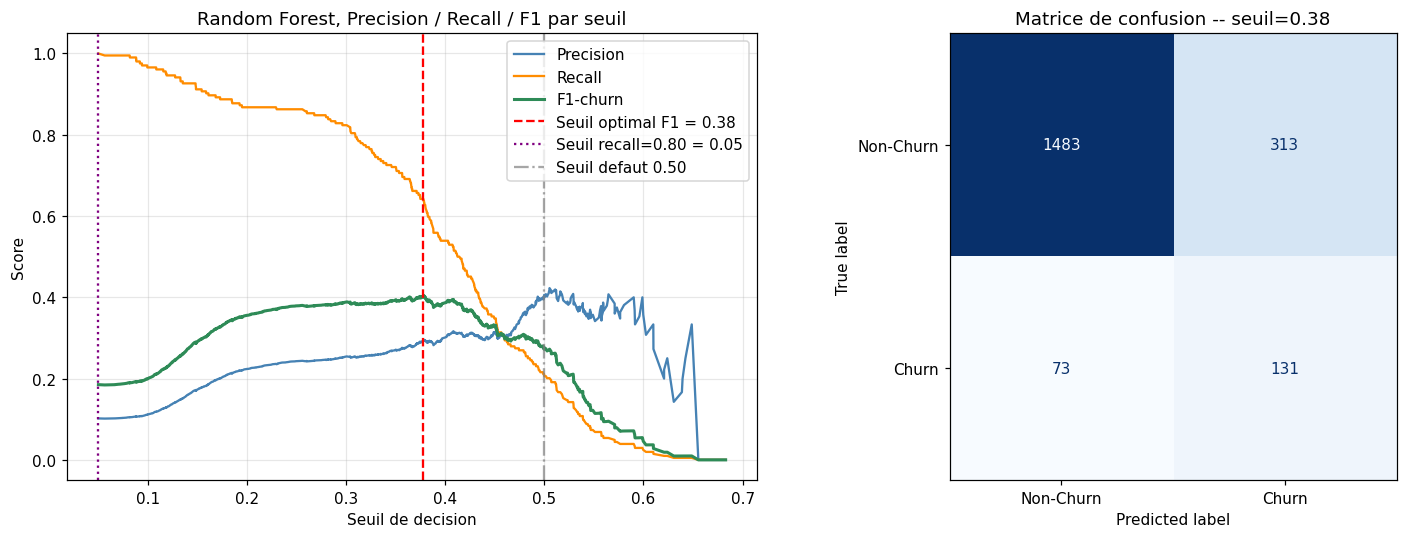

Figure sauvegardee : fig_rf_threshold.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe precision / recall / F1 selon le seuil
ax = axes[0]
ax.plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
ax.plot(thresholds, recalls[:-1],    label="Recall",    color="darkorange")
ax.plot(thresholds, f1_scores,       label="F1-churn",  color="seagreen", linewidth=2)
ax.axvline(optimal_threshold, color="red",    linestyle="--",
           label=f"Seuil optimal F1 = {optimal_threshold:.2f}")
if threshold_recall80 is not None:
    ax.axvline(threshold_recall80, color="purple", linestyle=":",
               label=f"Seuil recall=0.80 = {threshold_recall80:.2f}")
ax.axvline(0.50, color="gray", linestyle="-.", alpha=0.7, label="Seuil defaut 0.50")
ax.set_xlabel("Seuil de decision")
ax.set_ylabel("Score")
ax.set_title("Random Forest, Precision / Recall / F1 par seuil")
ax.legend()
ax.grid(alpha=0.3)

# Matrice de confusion avec seuil optimal
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Churn", "Churn"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Matrice de confusion -- seuil={optimal_threshold:.2f}")

plt.tight_layout()
plt.savefig("../data/processed/fig_rf_threshold.png", bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : fig_rf_threshold.png")

In [20]:
# Sauvegarde du seuil optimal pour l'API FastAPI
threshold_data = {
    "threshold": optimal_threshold,
    "threshold_recall80": threshold_recall80,
    "recall_at_optimal": float(recalls[optimal_idx]),
    "precision_at_optimal": float(precisions[optimal_idx]),
    "f1_at_optimal": float(f1_scores[optimal_idx]),
}
from src.data.loader import PROCESSED_DIR
import json
(PROCESSED_DIR / "threshold_random_forest.json").write_text(
    json.dumps(threshold_data, indent=2)
)
print(f"Seuil optimal sauvegarde : {optimal_threshold:.4f}")
print(f"  -> recall  : {recalls[optimal_idx]:.4f}")
print(f"  -> precision : {precisions[optimal_idx]:.4f}")
print(f"  -> F1-churn  : {f1_scores[optimal_idx]:.4f}")

Seuil optimal sauvegarde : 0.3780
  -> recall  : 0.6422
  -> precision : 0.2950
  -> F1-churn  : 0.4043


## 4. Enregistrement MLflow

In [21]:
setup_mlflow(EXPERIMENT_CHURN)

params = {
    'n_estimators': model.n_estimators,
    'max_depth': model.max_depth,
    'min_samples_leaf': model.min_samples_leaf,
    'max_features': model.max_features,
    'class_weight': 'balanced',
    'cv_auc_mean': float(cv_auc.mean()),
    'cv_auc_std': float(cv_auc.std()),
}

run_id = log_classification_run(
    model=model,
    model_name='Random Forest',
    params=params,
    metrics=metrics,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
)

joblib.dump(model, PROCESSED_DIR / 'model_random_forest.joblib')
print(f"Run MLflow : {run_id}")

Expérience MLflow : 'churn_classification' (id=1)
Run enregistré : Random Forest | run_id=0661c64c73fe4f8fbe0cab50ab4f3f8e
  AUC-ROC : 0.8093
  F1 (classe 1) : 0.2727
🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/0661c64c73fe4f8fbe0cab50ab4f3f8e
🧪 View experiment at: http://localhost:5000/#/experiments/1
Run MLflow : 0661c64c73fe4f8fbe0cab50ab4f3f8e


## 5. Recherche d'hyperparametres - RandomizedSearchCV

Le Random Forest a plusieurs hyperparametres importants a regler ensemble :
le nombre d'arbres, la profondeur maximale et le nombre minimum de samples par feuille.
Une recherche aleatoire est plus efficace qu'une grille complete ici.

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(8, 25),
    'min_samples_leaf': randint(2, 15),
    'max_features': ['sqrt', 'log2', 0.5],
}

base_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_rf = RandomizedSearchCV(
    base_rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search_rf.fit(X_train, y_train)

print("Meilleurs hyperparametres :")
for k, v in search_rf.best_params_.items():
    print(f"  {k} : {v}")
print(f"\nMeilleur AUC-ROC CV (3 plis) : {search_rf.best_score_:.4f}")

best_rf = search_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test)
y_proba_rf_opt = best_rf.predict_proba(X_test)[:, 1]
metrics_rf_opt = compute_classification_metrics(y_test.values, y_pred_rf_opt, y_proba_rf_opt)

print(f"\nAUC-ROC test (modele optimise) : {metrics_rf_opt['auc_roc']:.4f}")
print(f"AUC-ROC test (modele de base)   : {metrics['auc_roc']:.4f}")
print(f"Gain : {metrics_rf_opt['auc_roc'] - metrics['auc_roc']:+.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs hyperparametres :
  max_depth : 21
  max_features : log2
  min_samples_leaf : 11
  n_estimators : 364

Meilleur AUC-ROC CV (3 plis) : 0.8069

AUC-ROC test (modele optimise) : 0.8070
AUC-ROC test (modele de base)   : 0.8093
Gain : -0.0023


## 5b. Enregistrement MLflow -- modele tuned (best_rf)

On enregistre le modele issu de RandomizedSearchCV dans MLflow avec ses metriques propres.
Si best_rf a une meilleure AUC que le modele de base, il ecrase le .joblib de production.

In [23]:
setup_mlflow(EXPERIMENT_CHURN)

params_best_rf = {
    **search_rf.best_params_,
    'class_weight': 'balanced',
    'cv_auc_mean': float(cv_auc.mean()),
    'cv_auc_std': float(cv_auc.std()),
    'search': 'RandomizedSearchCV',
    'n_iter': 20,
}

# Calcul des metriques completes sur best_rf
metrics_best_rf = compute_classification_metrics(
    y_test.values, y_pred_rf_opt, y_proba_rf_opt
)

run_id_best = log_classification_run(
    model=best_rf,
    model_name='Random Forest (tuned)',
    params=params_best_rf,
    metrics=metrics_best_rf,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
)

# On ecrase le .joblib uniquement si best_rf est meilleur
if metrics_best_rf['auc_roc'] > metrics['auc_roc']:
    joblib.dump(best_rf, PROCESSED_DIR / 'model_random_forest.joblib')
    print(f"Modele de production mis a jour : best_rf (AUC {metrics_best_rf['auc_roc']:.4f})")
else:
    print(f"Modele de base conserve en production (AUC {metrics['auc_roc']:.4f} > {metrics_best_rf['auc_roc']:.4f})")
    print(f"best_rf logue dans MLflow pour comparaison (run_id={run_id_best})")

print(f"Run MLflow best_rf : {run_id_best}")

Expérience MLflow : 'churn_classification' (id=1)
Run enregistré : Random Forest (tuned) | run_id=1039f335085d4d02b58c111510a8d252
  AUC-ROC : 0.8070
  F1 (classe 1) : 0.3707
🏃 View run Random Forest (tuned) at: http://localhost:5000/#/experiments/1/runs/1039f335085d4d02b58c111510a8d252
🧪 View experiment at: http://localhost:5000/#/experiments/1
Modele de base conserve en production (AUC 0.8093 > 0.8070)
best_rf logue dans MLflow pour comparaison (run_id=1039f335085d4d02b58c111510a8d252)
Run MLflow best_rf : 1039f335085d4d02b58c111510a8d252
